# DeckAura DeepSeek Model Quality & Unit Economics — 15 Aug 2026

Reproducible offline comparison of the free-reading Flash control and full-Pro challenger. The same 12 synthetic questions, card positions and orientations were used across EN/TR/ES/PT/DE. Model identities were hidden from the judge.

## tl;dr

Pro has a modest offline quality edge, but it is not yet a proven commercial winner. Both variants still have card-specific hard failures and frequent deterministic fallbacks. The incremental model cost is tiny relative to a paid order, so a fixed randomized experiment should choose the winner on contribution profit per assigned eligible visitor, not on token price or historical rescue cohorts.

## Context & Methods

This is an offline diagnostic plus unit-economics analysis for the free-reading answer stage. Blind quality uses five equally weighted 1–5 dimensions: directness, card evidence, groundedness, language naturalness and useful next step. Technical results come from the same endpoint contract used for both variants. Token costs are computed from observed benchmark token counts. Re-running requires Python 3 with pandas, matplotlib and IPython; the two source JSON files must remain beside the notebook.

### Key Assumptions

- Historical Flash-only purchase rate (0.167%) is context, not a causal baseline.
- Break-even examples use net contribution per verified order after discounts, refunds, payment fees and fulfillment—not gross checkout price.
- The new DeepSeek schedule is effective 16 Aug 2026 at 16:00 UTC. Its peak rates apply 01:00–04:00 and 06:00–10:00 UTC; off-peak rates apply outside those windows.
- `reading_id LIKE 'benchmark_%'` is synthetic traffic and must be excluded from online conversion analysis.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

HERE = Path.cwd()
benchmark = json.loads((HERE / 'deepseek-model-benchmark-20260815.json').read_text(encoding='utf-8'))
judgement = json.loads((HERE / 'deepseek-model-blind-judgement-fixed-20260815.json').read_text(encoding='utf-8'))
mapping = {'en_contact': {'A': 'pro_full', 'B': 'flash_control'}, 'en_feelings': {'A': 'flash_control', 'B': 'pro_full'}, 'en_career': {'A': 'pro_full', 'B': 'flash_control'}, 'tr_contact': {'A': 'flash_control', 'B': 'pro_full'}, 'tr_feelings': {'A': 'pro_full', 'B': 'flash_control'}, 'tr_decision': {'A': 'flash_control', 'B': 'pro_full'}, 'es_contact': {'A': 'pro_full', 'B': 'flash_control'}, 'es_career': {'A': 'flash_control', 'B': 'pro_full'}, 'pt_feelings': {'A': 'pro_full', 'B': 'flash_control'}, 'pt_decision': {'A': 'flash_control', 'B': 'pro_full'}, 'de_contact': {'A': 'pro_full', 'B': 'flash_control'}, 'de_decision': {'A': 'flash_control', 'B': 'pro_full'}}
benchmark_usage = [{'variant': 'flash_control', 'model': 'DeepSeek Flash', 'answers': 12, 'calls': 19, 'input_tokens': 31697, 'cached_input_tokens': 27520, 'uncached_input_tokens': 4177, 'output_tokens': 4250, 'legacy_cost_micros': 1861, 'avg_call_latency_ms': 4179.4, 'median_call_latency_ms': 3842.0, 'p95_call_latency_ms': 5860.8}, {'variant': 'pro_full', 'model': 'DeepSeek Pro', 'answers': 12, 'calls': 19, 'input_tokens': 31642, 'cached_input_tokens': 24832, 'uncached_input_tokens': 6810, 'output_tokens': 4397, 'legacy_cost_micros': 6887, 'avg_call_latency_ms': 4986.1, 'median_call_latency_ms': 4907.0, 'p95_call_latency_ms': 6485.5}]
production_usage = [{'stage': 'initial', 'model': 'DeepSeek Flash', 'calls': 3394, 'cost_micros': 776850, 'avg_cost_micros': 228.89, 'median_latency_ms': 2858.5, 'p95_latency_ms': 3883.7}, {'stage': 'length retry', 'model': 'DeepSeek Flash', 'calls': 38, 'cost_micros': 10971, 'avg_cost_micros': 288.71, 'median_latency_ms': 3919.5, 'p95_latency_ms': 5300.8}, {'stage': 'quality retry', 'model': 'DeepSeek Flash', 'calls': 585, 'cost_micros': 143429, 'avg_cost_micros': 245.18, 'median_latency_ms': 2869.0, 'p95_latency_ms': 4029.4}]
historical_cohorts = [{'cohort': 'Flash-only', 'readings': 7197, 'orders': 12, 'observed_purchase_pct': 0.167, 'gross_revenue_usd': 117.81, 'avg_ai_cost_micros': 252.76}, {'cohort': 'Historical Pro rescue selected', 'readings': 290, 'orders': 0, 'observed_purchase_pct': 0.0, 'gross_revenue_usd': 0.0, 'avg_ai_cost_micros': 1052.2}]
pricing = {'Legacy recomputed (15 Aug)': {'flash_control': {'cached': 0.0028, 'uncached': 0.14, 'output': 0.28}, 'pro_full': {'cached': 0.003625, 'uncached': 0.435, 'output': 0.87}}, '16 Aug off-peak': {'flash_control': {'cached': 0.007, 'uncached': 0.22, 'output': 0.66}, 'pro_full': {'cached': 0.022, 'uncached': 0.66, 'output': 1.98}}, '16 Aug peak': {'flash_control': {'cached': 0.014, 'uncached': 0.44, 'output': 1.32}, 'pro_full': {'cached': 0.044, 'uncached': 1.32, 'output': 3.96}}}
BASELINE_PURCHASE_PCT = 0.167
pd.set_option('display.max_columns', 30)

## Data

Inputs are the saved 12-fixture benchmark, its fixed blind judgement, exact benchmark token/cost aggregates from `deckaura.ai_usage_events`, seven-day production usage aggregates and a 14-day observational purchase cohort. The assertions below make missing fixtures, incomplete arms and token-accounting mismatches fail loudly.

In [2]:
assert len(mapping) == 12
assert len(judgement['cases']) == 12
assert set(mapping) == {case['fixtureId'] for case in judgement['cases']}
assert all(set(sides.values()) == {'flash_control', 'pro_full'} for sides in mapping.values())
assert len(benchmark['results']) == 24
assert set(row['variant'] for row in benchmark['results']) == {'flash_control', 'pro_full'}
assert all(row['cached_input_tokens'] + row['uncached_input_tokens'] == row['input_tokens'] for row in benchmark_usage)
print('Input checks passed: 12 fixtures, 24 answers, both variants, balanced token accounting.')

Input checks passed: 12 fixtures, 24 answers, both variants, balanced token accounting.


## Results

### 1. Blind answer quality

Scores are decoded only after judging. A hard failure marks missing or incorrect card-specific evidence; it is a guardrail, not another averaged dimension.

In [3]:
dims = ['directness','card_evidence','groundedness','language_naturalness','useful_next_step']
rows = []
winner_counts = {'flash_control': 0, 'pro_full': 0, 'tie': 0}
for case in judgement['cases']:
    fixture = case['fixtureId']
    for side in ['A','B']:
        variant = mapping[fixture][side]
        scores = case['scores'][side]
        rows.append({'fixture': fixture, 'variant': variant, **scores, 'hard_fail': bool(case['hard_failures'][side])})
    pref = case['preference']
    winner_counts['tie' if pref == 'tie' else mapping[fixture][pref]] += 1
blind = pd.DataFrame(rows)
blind_summary = blind.groupby('variant').agg(**{d:(d,'mean') for d in dims}, hard_fails=('hard_fail','sum')).reset_index()
blind_summary['mean_score'] = blind_summary[dims].mean(axis=1)
blind_summary['wins'] = blind_summary['variant'].map(winner_counts)
blind_summary['ties'] = winner_counts['tie']
display(blind_summary.round(3))

,variant,directness,card_evidence,groundedness,language_naturalness,useful_next_step,hard_fails,mean_score,wins,ties
0,flash_control,3.500,3.333,4.75,4.00,3.833,5,3.883,1,6
1,pro_full,3.917,3.417,4.75,4.25,4.083,6,4.083,5,6


### 2. Technical contract and fallback rate

A technical pass means the endpoint response satisfied the contract and safety audit. Deterministic fallback frequency remains an important quality guardrail even when the request technically passes.

In [4]:
technical = pd.DataFrame(benchmark['results'])
technical_summary = technical.groupby('variant').agg(answers=('fixtureId','size'), technical_passes=('audit', lambda s: sum(bool(x.get('ok')) for x in s)), deterministic_fallbacks=('servedModel', lambda s: sum(x == 'deterministic' for x in s)), mean_endpoint_ms=('latencyMs','mean')).reset_index()
technical_summary['technical_pass_rate_pct'] = 100 * technical_summary['technical_passes'] / technical_summary['answers']
technical_summary['fallback_rate_pct'] = 100 * technical_summary['deterministic_fallbacks'] / technical_summary['answers']
display(technical_summary.round(2))

,variant,answers,technical_passes,deterministic_fallbacks,mean_endpoint_ms,technical_pass_rate_pct,fallback_rate_pct
0,flash_control,12,12,10,11910.33,100.0,83.33
1,pro_full,12,12,7,13039.58,100.0,58.33


### 3. Observed and scheduled model cost

The first row uses exact observed database cost. The legacy recomputation and 16 Aug scenarios apply published rates to the same observed cached, uncached and output tokens, isolating the pricing effect.

In [5]:
usage = pd.DataFrame(benchmark_usage)
cost_rows = []
for _, row in usage.iterrows():
    cost_rows.append({'variant': row['variant'], 'model': row['model'], 'pricing_window': 'Observed / legacy DB', 'cost_per_answer_usd': row['legacy_cost_micros'] / 1_000_000 / row['answers']})
    for window, rates_by_variant in pricing.items():
        rates = rates_by_variant[row['variant']]
        micros = row['cached_input_tokens'] * rates['cached'] + row['uncached_input_tokens'] * rates['uncached'] + row['output_tokens'] * rates['output']
        cost_rows.append({'variant': row['variant'], 'model': row['model'], 'pricing_window': window, 'cost_per_answer_usd': micros / 1_000_000 / row['answers']})
costs = pd.DataFrame(cost_rows)
scenario_order = ['Observed / legacy DB', *pricing.keys()]
display(costs.pivot(index='pricing_window', columns='model', values='cost_per_answer_usd').reindex(scenario_order).round(6))

model,DeepSeek Flash,DeepSeek Pro
pricing_window,,
Observed / legacy DB,0.000155,0.000574
Legacy recomputed (15 Aug),0.000154,0.000573
16 Aug off-peak,0.000326,0.001146
16 Aug peak,0.000653,0.002291


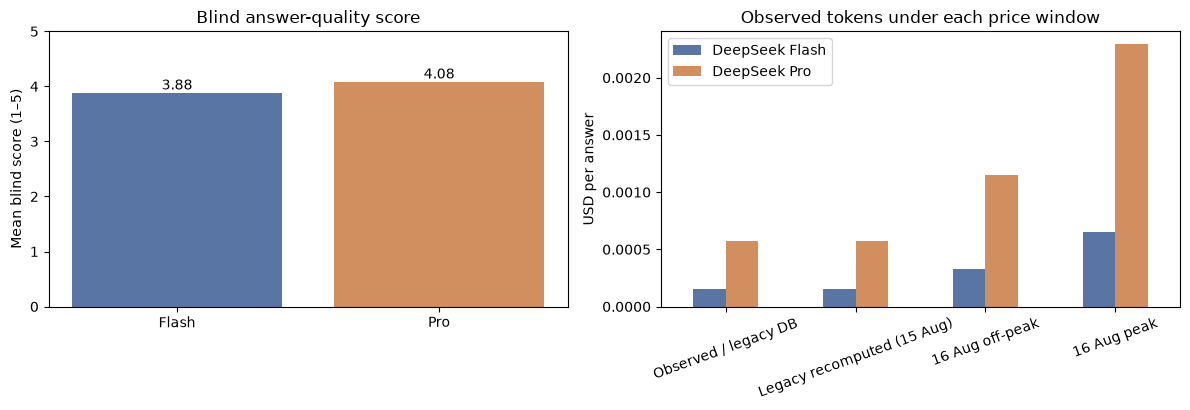

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
q = blind_summary.set_index('variant').loc[['flash_control','pro_full']]
axes[0].bar(['Flash','Pro'], q['mean_score'], color=['#5875A4','#D18F5F'])
axes[0].set_ylim(0,5); axes[0].set_ylabel('Mean blind score (1–5)'); axes[0].set_title('Blind answer-quality score')
for i,v in enumerate(q['mean_score']): axes[0].text(i, v+0.06, f'{v:.2f}', ha='center')
pivot = costs.pivot(index='pricing_window', columns='model', values='cost_per_answer_usd').reindex(scenario_order)
pivot.plot(kind='bar', ax=axes[1], color=['#5875A4','#D18F5F'])
axes[1].set_xlabel(''); axes[1].set_ylabel('USD per answer'); axes[1].set_title('Observed tokens under each price window'); axes[1].tick_params(axis='x', rotation=20); axes[1].legend(title='')
plt.tight_layout(); plt.show()

### 4. Break-even conversion lift

Absolute lift is the additional paid-order percentage points needed for Pro to cover its incremental AI cost. Relative lift compares that absolute requirement with the observational 0.167% Flash-only purchase rate; it is a planning ratio, not a forecast.

In [7]:
break_even_rows = []
for window in scenario_order:
    p = costs[costs.pricing_window == window].set_index('variant').cost_per_answer_usd
    delta = p['pro_full'] - p['flash_control']
    for margin in [5,10,15]:
        lift_fraction = delta / margin
        absolute_lift_pp = 100 * lift_fraction
        break_even_rows.append({'pricing_window':window,'net_contribution_per_order_usd':margin,'incremental_cost_usd':delta,'absolute_cvr_lift_pp':absolute_lift_pp,'relative_lift_pct_vs_0_167_baseline':100*absolute_lift_pp/BASELINE_PURCHASE_PCT,'one_extra_order_per_answers':1/lift_fraction})
break_even = pd.DataFrame(break_even_rows)
display(break_even.round({'incremental_cost_usd':6,'absolute_cvr_lift_pp':5,'relative_lift_pct_vs_0_167_baseline':2,'one_extra_order_per_answers':0}))

,pricing_window,net_contribution_per_order_usd,incremental_cost_usd,absolute_cvr_lift_pp,relative_lift_pct_vs_0_167_baseline,one_extra_order_per_answers
0,Observed / legacy DB,5,0.000419,0.00838,5.02,11938.0
1,Observed / legacy DB,10,0.000419,0.00419,2.51,23876.0
2,Observed / legacy DB,15,0.000419,0.00279,1.67,35814.0
3,Legacy recomputed (15 Aug),5,0.000419,0.00838,5.02,11938.0
4,Legacy recomputed (15 Aug),10,0.000419,0.00419,2.51,23876.0
5,Legacy recomputed (15 Aug),15,0.000419,0.00279,1.67,35814.0
6,16 Aug off-peak,5,0.000819,0.01638,9.81,6104.0
7,16 Aug off-peak,10,0.000819,0.00819,4.91,12207.0
8,16 Aug off-peak,15,0.000819,0.00546,3.27,18311.0
9,16 Aug peak,5,0.001638,0.03277,19.62,3052.0


### 5. Historical conversion context

These are observational cohorts. The Pro-rescue group was selected after earlier difficulty/failure, so comparing its purchase rate with Flash-only traffic creates selection bias.

In [8]:
hist = pd.DataFrame(historical_cohorts)
display(hist)
display(Markdown('**Important:** the historical Pro-rescue rows are a selected failure cohort, not a randomized experiment; their zero purchases do not prove that Pro reduces conversion.'))

,cohort,readings,orders,observed_purchase_pct,gross_revenue_usd,avg_ai_cost_micros
0,Flash-only,7197,12,0.167,117.81,252.76
1,Historical Pro rescue selected,290,0,0.000,0.00,1052.20


**Important:** the historical Pro-rescue rows are a selected failure cohort, not a randomized experiment; their zero purchases do not prove that Pro reduces conversion.

## Takeaways

Use the offline benchmark to decide whether Pro is safe and promising enough to test—not to declare a revenue winner. Online assignment must be stable for the full test, and purchase attribution must inner-join the server assignment by `reading_id + variant`. Primary KPI: `(net contribution from verified orders − all AI cost) / assigned eligible visitors`. Guardrails: card-evidence hard failures, deterministic fallback, private-state/safety violations, wrong language/card, p95 latency, errors/timeouts, abandonment, refunds and disputes.

In [9]:
pro = blind_summary.set_index('variant').loc['pro_full']
flash = blind_summary.set_index('variant').loc['flash_control']
off = costs[costs.pricing_window == '16 Aug off-peak'].set_index('variant').cost_per_answer_usd
delta = off['pro_full'] - off['flash_control']
display(Markdown(f'''## Decision

- **Offline quality:** Pro won {int(pro.wins)} cases, Flash won {int(flash.wins)}, and {int(pro.ties)} tied. Mean score was {pro.mean_score:.2f} vs {flash.mean_score:.2f}.
- **Guardrail:** Pro still had {int(pro.hard_fails)} card-evidence hard failures vs {int(flash.hard_fails)} for Flash; model replacement alone does not solve the answer system.
- **Cost:** observed 16 Aug off-peak incremental cost is about ${delta:.6f} per free answer. At $15 net contribution per order, break-even needs only {100*delta/15:.4f} percentage points of absolute conversion lift.
- **Recommendation:** keep Flash as control, deploy attribution and quality telemetry, then run a fixed server-side experiment. Do not change the assignment threshold mid-test; use a new experiment version for any ramp. Choose the winner on contribution profit per assigned eligible visitor, with safety, fallback, latency and refund guardrails.''' ))

## Decision

- **Offline quality:** Pro won 5 cases, Flash won 1, and 6 tied. Mean score was 4.08 vs 3.88.
- **Guardrail:** Pro still had 6 card-evidence hard failures vs 5 for Flash; model replacement alone does not solve the answer system.
- **Cost:** observed 16 Aug off-peak incremental cost is about $0.000819 per free answer. At $15 net contribution per order, break-even needs only 0.0055 percentage points of absolute conversion lift.
- **Recommendation:** keep Flash as control, deploy attribution and quality telemetry, then run a fixed server-side experiment. Do not change the assignment threshold mid-test; use a new experiment version for any ramp. Choose the winner on contribution profit per assigned eligible visitor, with safety, fallback, latency and refund guardrails.

## Sources and limitations

- DeepSeek account overview inspected read-only on 15 Aug 2026; no API key was created or changed.
- Supabase `deckaura.ai_usage_events`: 7-day production usage and the 03:09–03:14 UTC benchmark window; `reading_id LIKE 'benchmark_%'` is synthetic and must be excluded from online winner analysis.
- Supabase `deckaura.funnel_events`: verified Shopify purchase events and gross line revenue. Gross revenue is not net contribution; discounts, refunds, payment fees and paid-reading fulfillment costs must be subtracted.
- Official DeepSeek pricing: https://api-docs.deepseek.com/quick_start/pricing/ (effective-window rates captured 15 Aug 2026).
- Twelve offline fixtures are diagnostic, not statistically sufficient to establish conversion lift. Historical Pro rescue usage is selection-biased.
- Benchmark cache-hit rates are unusually high, so the scenario costs should be treated as observed-case estimates rather than guaranteed production averages.